In [1]:
# Perm so we can import from src/
import sys
sys.path.append("..")  

# Binance Data
from src.data_loader import fetch_binance_klines
import pandas as pd
import matplotlib.pyplot as plt

# Fetch BTC daily data from 2020
btc = fetch_binance_klines(
    symbol="BTCUSDT",
    interval="1d",
    start_date="2020-01-01"
)

print(btc.shape)
print(f"Date range: {btc['date'].min()} to {btc['date'].max()}")
btc.head()

(2319, 6)
Date range: 2020-01-01 00:00:00 to 2026-05-07 00:00:00


,date,open,high,low,close,volume
0,2020-01-01,7195.24,7255.0,7175.15,7200.85,16792.388165
1,2020-01-02,7200.77,7212.5,6924.74,6965.71,31951.483932
2,2020-01-03,6965.49,7405.0,6871.04,7344.96,68428.500451
3,2020-01-04,7345.00,7404.0,7272.21,7354.11,29987.974977
4,2020-01-05,7354.19,7495.0,7318.00,7358.75,38331.085604


In [2]:
# Save raw data
btc.to_csv("../data/raw/btc_prices.csv", index=False)

In [3]:
# Looking for missing values
btc.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [4]:
# Describe
btc_des = btc.iloc[:,1:]
btc_des.describe()

,open,high,low,close,volume
count,2319.000000,2319.000000,2319.000000,2319.000000,2319.000000
mean,48732.793661,49732.298499,47667.831660,48764.649784,70960.564526
std,31324.516255,31788.311375,30820.452552,31319.741312,85544.916099
min,4800.010000,5365.420000,3782.130000,4800.000000,2235.972220
25%,23015.525000,23474.905000,22558.505000,23041.770000,24312.378107
50%,42158.850000,43079.000000,41250.000000,42201.130000,43559.747190
75%,68004.020000,69275.480000,66600.060000,68020.855000,76342.507571
max,124658.540000,126199.630000,123084.000000,124658.540000,760705.362783


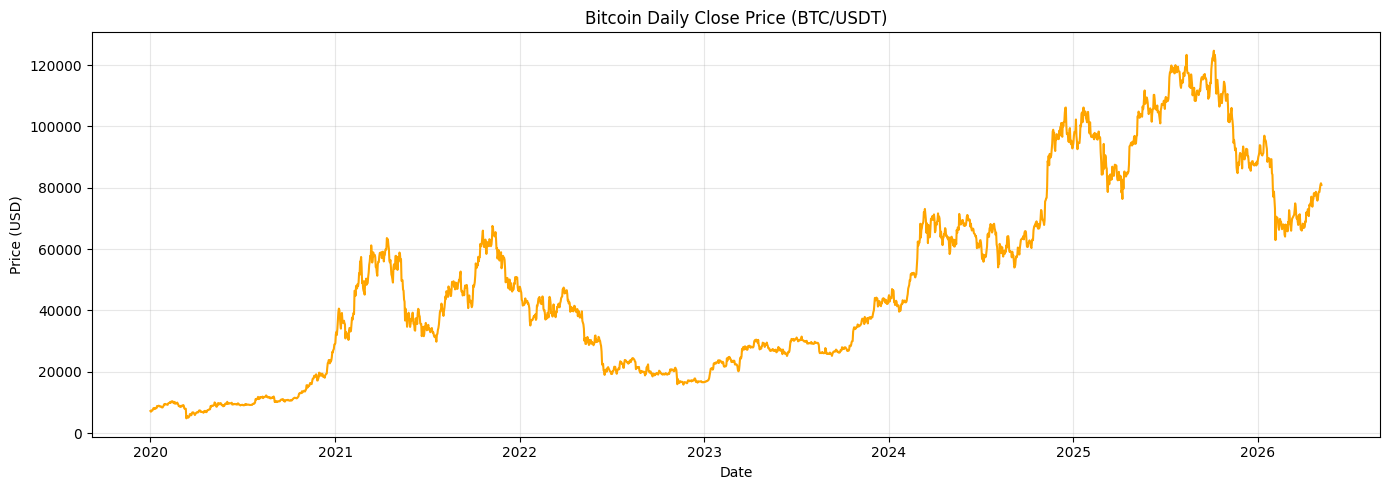

In [5]:
# Price
plt.figure(figsize=(14, 5))
plt.plot(btc["date"], btc["close"], color="orange", linewidth=1.5)
plt.title("Bitcoin Daily Close Price (BTC/USDT)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

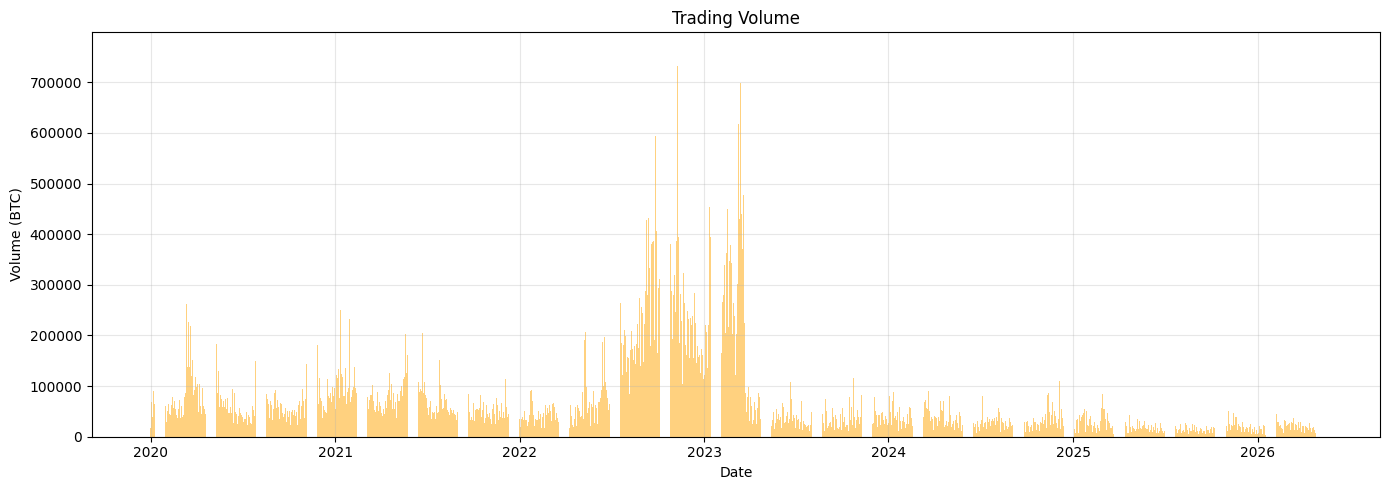

In [6]:
# Volume 
plt.figure(figsize=(14, 5))
plt.bar(btc["date"], btc["volume"], color="orange", alpha=0.5)
plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume (BTC)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Fear & Greed Data
from src.data_loader import fetch_fear_greed_index

# Fetch all available data
fg = fetch_fear_greed_index()
fg = fg[fg["date"] >= "2020-01-01"].reset_index(drop=True)

print(fg.shape)
print(f"Date range: {fg['date'].min()} to {fg['date'].max()}")
fg.head()

(2318, 3)
Date range: 2020-01-01 00:00:00 to 2026-05-07 00:00:00


,date,fear_greed,fear_greed_label
0,2020-01-01,37,Fear
1,2020-01-02,39,Fear
2,2020-01-03,38,Fear
3,2020-01-04,38,Fear
4,2020-01-05,39,Fear


In [8]:
# Save raw data
fg.to_csv("../data/raw/fear_greed.csv", index=False)

In [9]:
# Looking for missing values
fg.isnull().sum()

date                0
fear_greed          0
fear_greed_label    0
dtype: int64

In [10]:
# Describe
fg_des = fg.iloc[:,1:]
fg_des.describe()

,fear_greed
count,2318.000000
mean,48.376618
std,22.689248
min,5.000000
25%,27.000000
50%,49.000000
75%,70.000000
max,95.000000


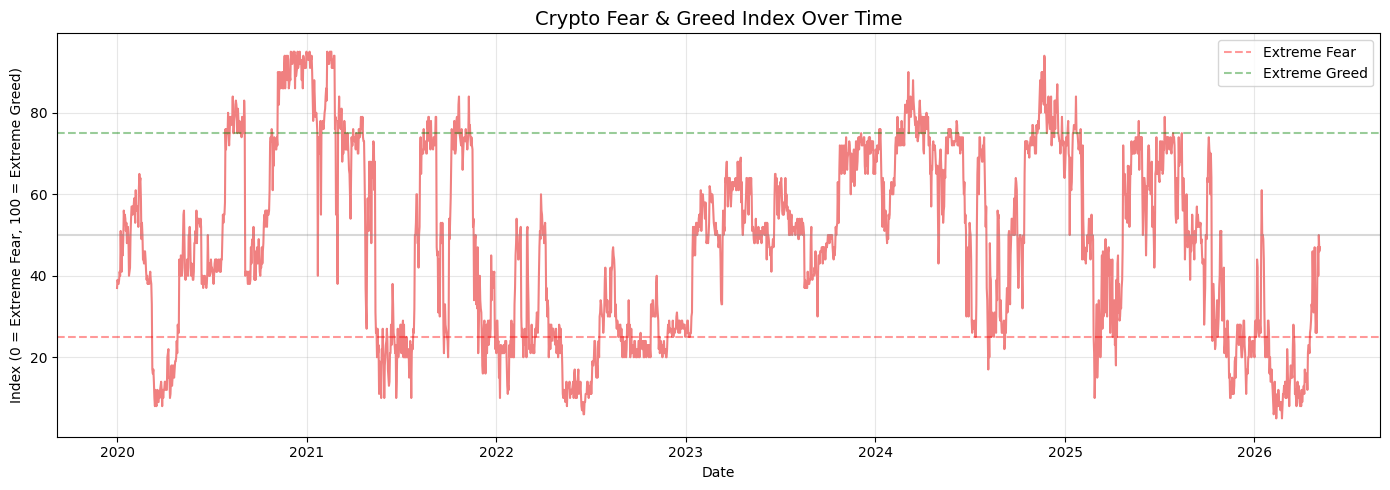

In [11]:
# Frer & Greed
plt.figure(figsize=(14, 5))
plt.plot(fg["date"], fg["fear_greed"], color="lightcoral")

# Add reference lines for the zones
plt.axhline(25, color="red", linestyle="--", alpha=0.4, label="Extreme Fear")
plt.axhline(75, color="green", linestyle="--", alpha=0.4, label="Extreme Greed")
plt.axhline(50, color="gray", linestyle="-", alpha=0.3)

plt.title("Crypto Fear & Greed Index Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Index (0 = Extreme Fear, 100 = Extreme Greed)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

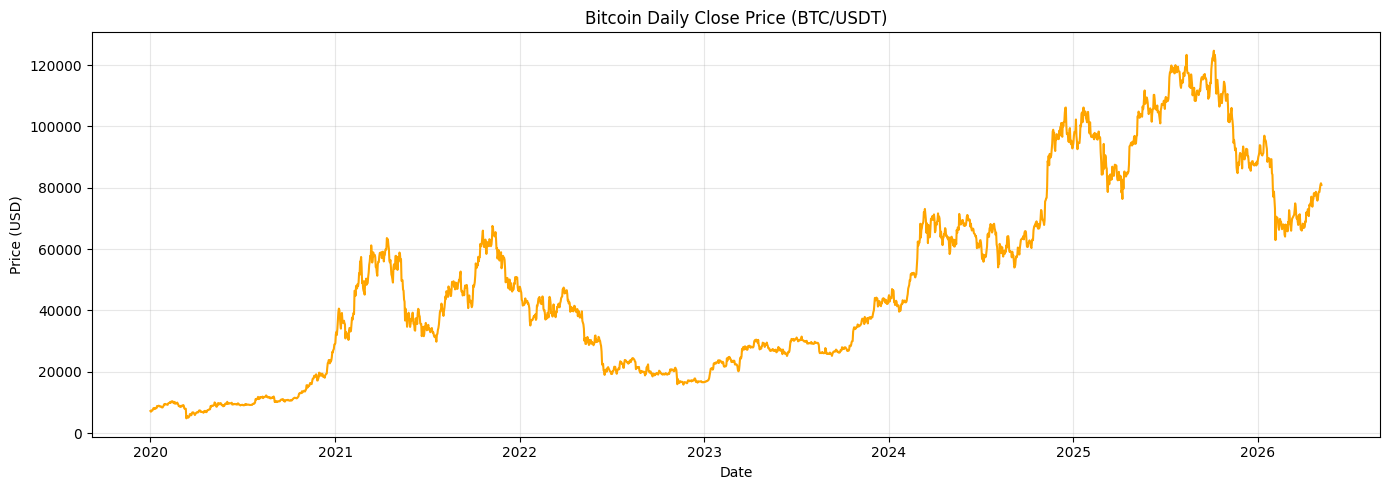

In [12]:
# Re-plot Price to compare
plt.figure(figsize=(14, 5))
plt.plot(btc["date"], btc["close"], color="orange", linewidth=1.5)
plt.title("Bitcoin Daily Close Price (BTC/USDT)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Blockchain Data
from src.data_loader import fetch_blockchain_metric

# Fetch hash rate (mining power)
hash_rate = fetch_blockchain_metric("hash-rate", timespan="all")
hash_rate = hash_rate[hash_rate["date"] >= "2020-01-01"].reset_index(drop=True)

# Fetch transaction count
n_tx = fetch_blockchain_metric("n-transactions", timespan="all")
n_tx = n_tx[n_tx["date"] >= "2020-01-01"].reset_index(drop=True)

print(f"Hash rate: {hash_rate.shape}")
print(f"Transactions: {n_tx.shape}")

Hash rate: (2315, 2)
Transactions: (2315, 2)


In [14]:
# Merge on date
onchain = hash_rate.merge(n_tx, on="date", how="outer")
onchain = onchain.sort_values("date").reset_index(drop=True)

print(f"Merged shape: {onchain.shape}")
onchain.head()

Merged shape: (2315, 3)


,date,hash_rate,n_transactions
0,2020-01-01,1.127185e+08,251735.0
1,2020-01-02,9.671772e+07,295567.0
2,2020-01-03,1.159241e+08,316517.0
3,2020-01-04,1.152381e+08,287215.0
4,2020-01-05,1.118084e+08,287779.0


In [15]:
# Save raw data
onchain.to_csv("../data/raw/onchain_metrics.csv", index=False)

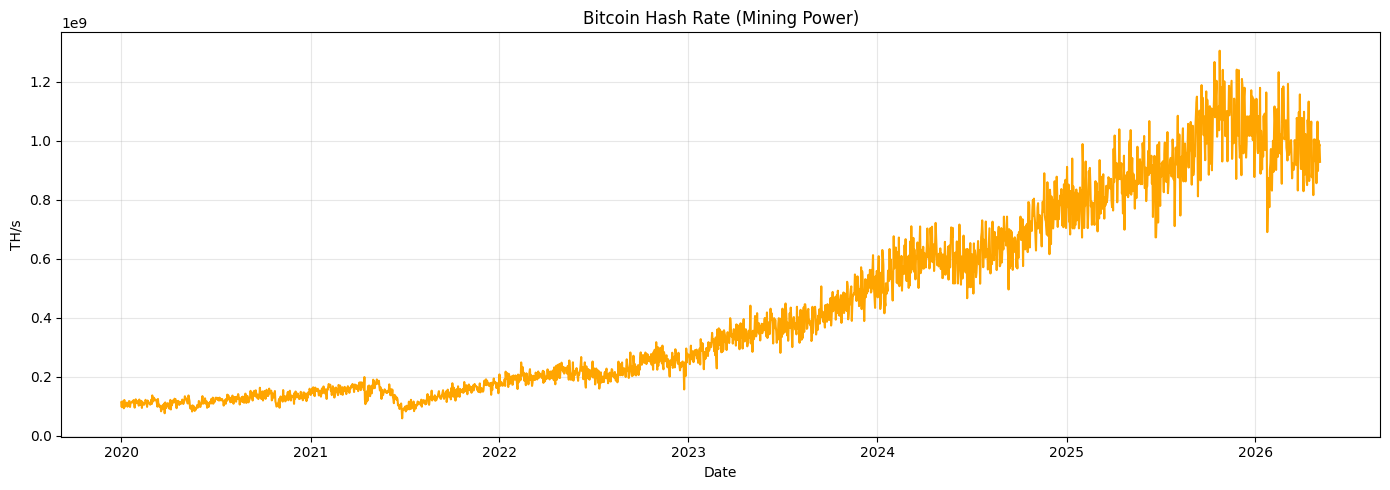

In [16]:
#Hash rate
plt.figure(figsize=(14, 5))
plt.plot(onchain["date"], onchain["hash_rate"], color="orange")
plt.title("Bitcoin Hash Rate (Mining Power)")
plt.xlabel("Date")
plt.ylabel("TH/s")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

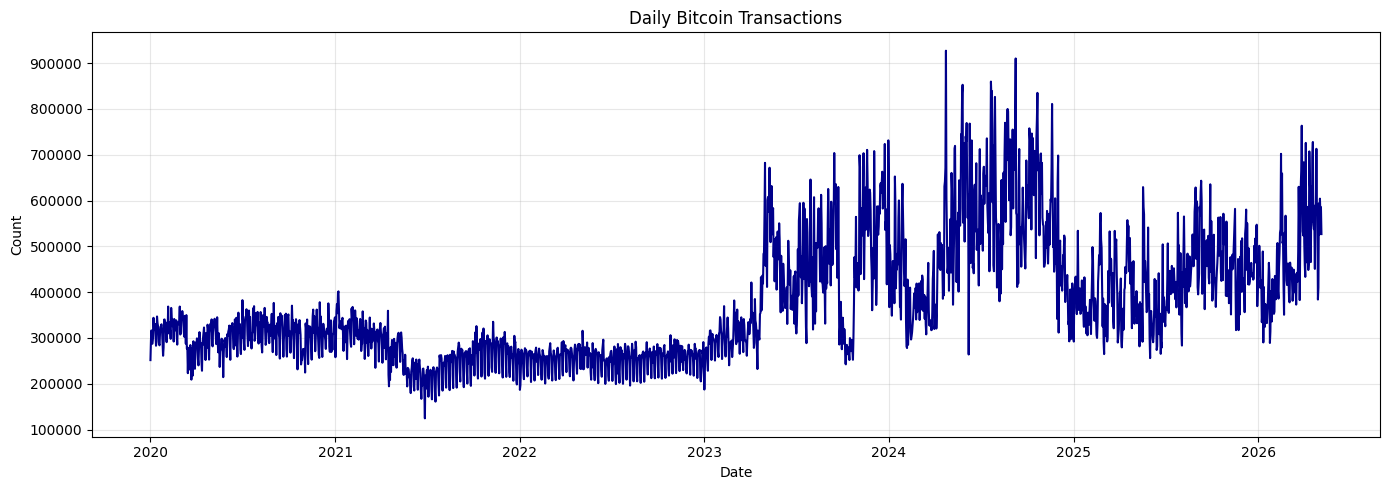

In [17]:
# Transactions
plt.figure(figsize=(14, 5))
plt.plot(onchain["date"], onchain["n_transactions"], color="darkblue")
plt.title("Daily Bitcoin Transactions")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Merge into big datasets
from src.data_loader import merge_all_sources

master = merge_all_sources(
    btc_path="../data/raw/btc_prices.csv",
    fg_path="../data/raw/fear_greed.csv",
    onchain_path="../data/raw/onchain_metrics.csv",
    start_date="2020-01-01"
)

print(f"Shape: {master.shape}")
print(f"Date range: {master['date'].min()} to {master['date'].max()}")
print(f"\nColumns: {list(master.columns)}")
master.head()

Shape: (2319, 9)
Date range: 2020-01-01 00:00:00 to 2026-05-07 00:00:00

Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'fear_greed', 'hash_rate', 'n_transactions']


,date,open,high,low,close,volume,fear_greed,hash_rate,n_transactions
0,2020-01-01,7195.24,7255.0,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0
1,2020-01-02,7200.77,7212.5,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0
2,2020-01-03,6965.49,7405.0,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0
3,2020-01-04,7345.00,7404.0,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0
4,2020-01-05,7354.19,7495.0,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0


In [20]:
print("Missing values per column:")
print(master.isnull().sum())

print(f"\nTotal rows: {len(master)}")
print(f"Rows with any missing data: {master.isnull().any(axis=1).sum()}")

Missing values per column:
date              0
open              0
high              0
low               0
close             0
volume            0
fear_greed        1
hash_rate         4
n_transactions    4
dtype: int64

Total rows: 2319
Rows with any missing data: 5


In [21]:
# Show columns that need fixing
missing_before = master.isnull().sum()
print("Before:")
print(missing_before[missing_before > 0])

# Forward-fill missing values
master = master.ffill()

# If anything is still NaN (very early rows), drop them
master = master.dropna().reset_index(drop=True)

print("\nAfter:")
print(master.isnull().sum().sum(), "missing values total")
print(f"Final shape: {master.shape}")

Before:
fear_greed        1
hash_rate         4
n_transactions    4
dtype: int64

After:
0 missing values total
Final shape: (2319, 9)


In [23]:
# Save processed data
master.to_csv("../data/processed/master_dataset.csv", index=False)